In [1]:
import cartopy.crs as ccrs
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import cftime

from ep_processing import *
from utils.visualization import draw_global_map, process_for_map

In [2]:
my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_generic_file_path = "_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"
my_pr_file_path = "pr" + my_generic_file_path
my_hfls_file_path = "hfls" + my_generic_file_path
my_wap_file_path = "wap" + my_generic_file_path

my_experiment_name = "amip"
my_runid = "agm-amip-test"
my_var_name = "hfls"
year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [3]:
# Daily precipitation 
da_pr_daily = get_ds(
        "pr",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_pr_file_path,
).pr

In [4]:
da_hfls_daily = get_ds(
        my_var_name,
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_hfls_file_path,
).hfls

In [5]:
da_hfls_daily

<xarray.DataArray 'hfls' (time: 2190, lat: 64, lon: 128)> Size: 72MB
dask.array<concatenate, shape=(2190, 64, 128), dtype=float32, chunksize=(1, 64, 128), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 18kB 2003-01-01 12:00:00 ... 2008-12-31 12:00:00
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
Attributes:
    standard_name:  surface_upward_latent_heat_flux
    long_name:      Surface Upward Latent Heat Flux
    comment:        The surface called 'surface' means the lower boundary of ...
    units:          W m-2
    original_name:  HFL
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2025-10-30T18:44:15Z altered by CMOR: Reordered dimension...

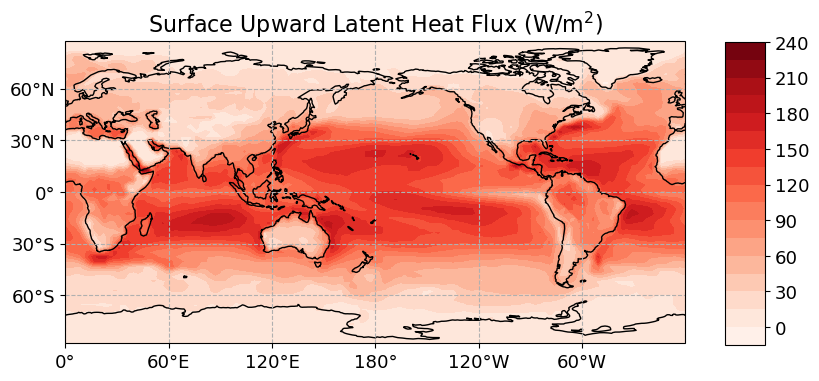

In [6]:
field_vals, lon_plt, lat_plt = process_for_map(da_hfls_daily.mean(dim="time"))

draw_global_map(
    lon_plt,
    lat_plt,
    field_vals,
    title = r"Surface Upward Latent Heat Flux (W/$\mathrm{m}^2$)",
    filled = True,
    show_fig = True,
    save_fig = False,
    levels = 16,
    cmap = "Reds",
    cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
    #bbox = [0, 360, -60, 60],
    #vmin = 0,
    #vmax = 2.5,
    draw_labels = False,
    label_contours = False,
    remove_cbar = False,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    # outfilename = "my_map" + ".png",
)

In [7]:
def get_anom(da, da_pr_daily, year_range):
    da_temporal_mean = da.mean(dim="time")
    
    anom_as_temporal_list = []

    for year in year_range:
        day_of_epe = select_fixed_year(da_pr_daily, year).idxmax(dim = "time")
        anom_current_year = (
                da.sel(time = day_of_epe) - da_temporal_mean
        )
        anom_as_temporal_list.append(anom_current_year)
    
    return xr.DataArray(
            data = anom_as_temporal_list,
            dims = ["time", "lat", "lon"],
            coords = dict(
                lon = da.lon.to_numpy(),
                lat = da.lat.to_numpy(),
                time = [year for year in year_range],
            ),
    )

In [8]:
da_hfls_anom = get_anom(da_hfls_daily, da_pr_daily, year_range)

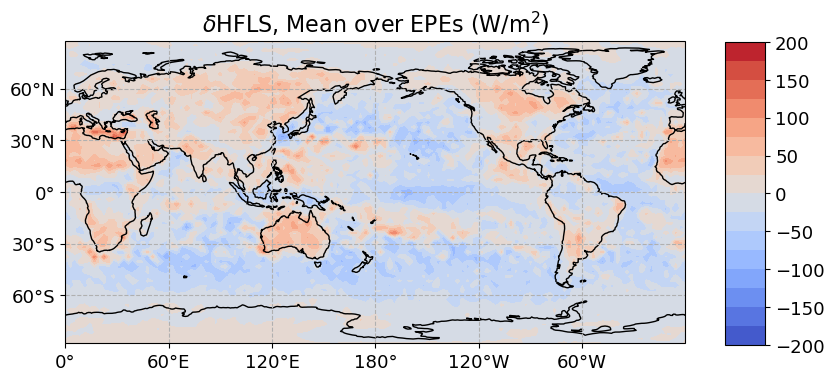

In [22]:
field_vals, lon_plt, lat_plt = process_for_map(da_hfls_anom.mean(dim="time"))

draw_global_map(
    lon_plt,
    lat_plt,
    field_vals,
    title = r"$\delta$HFLS, Mean over EPEs (W/$\mathrm{m}^2$)",
    filled = True,
    show_fig = True,
    save_fig = True,
    levels = 16,
    cmap = "coolwarm",
    cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
    #bbox = [0, 360, -60, 60],
    vmin = -200,
    vmax = 200,
    draw_labels = False,
    label_contours = False,
    remove_cbar = False,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    outfilename = "hfls_anom_epes" + ".png",
)

Get 500 hPa value of $\omega = \frac{\mathrm{d}p}{\mathrm{d}t}$ (stored as ``wap`` according to CMIP conventions).

In [10]:
da_wap_daily = get_ds(
        my_var_name,
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_wap_file_path,
).wap.sel(plev = 50000.)

In [11]:
da_wap_daily

<xarray.DataArray 'wap' (time: 2190, lat: 64, lon: 128)> Size: 72MB
dask.array<getitem, shape=(2190, 64, 128), dtype=float32, chunksize=(1, 64, 128), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 18kB 2003-01-01 12:00:00 ... 2008-12-31 12:00:00
    plev     float64 8B 5e+04
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
Attributes:
    standard_name:  lagrangian_tendency_of_air_pressure
    long_name:      Omega (=dp/dt)
    comment:        Bin 4 saves to one daily save, CMIP_table_comment: Omega ...
    units:          Pa s-1
    original_name:  OMET
    cell_methods:   time: mean
    cell_measures:  area: areacella
    history:        2025-10-30T18:45:15Z altered by CMOR: Reordered dimension...

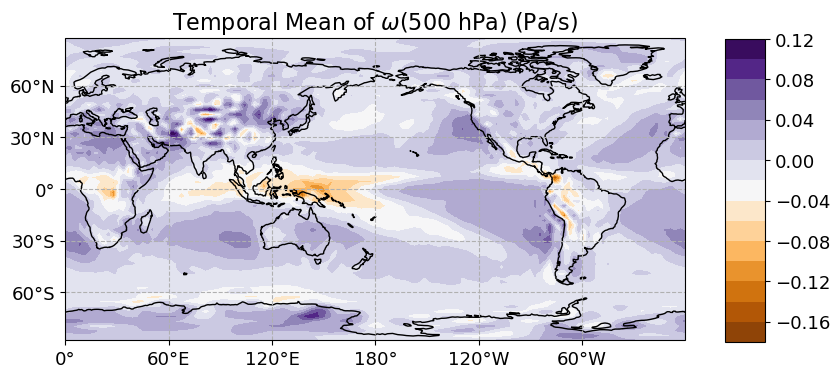

In [12]:
field_vals, lon_plt, lat_plt = process_for_map(da_wap_daily.mean(dim="time"))

draw_global_map(
    lon_plt,
    lat_plt,
    field_vals,
    title = r"Temporal Mean of $\omega$($500$ hPa) (Pa/s)",
    filled = True,
    show_fig = True,
    save_fig = False,
    levels = 16,
    cmap = "PuOr",
    cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
    #bbox = [0, 360, -60, 60],
    #vmin = 0,
    #vmax = 2.5,
    draw_labels = False,
    label_contours = False,
    remove_cbar = False,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    # outfilename = "my_map" + ".png",
)

In [13]:
da_wap_anom = get_anom(da_wap_daily, da_pr_daily, year_range)

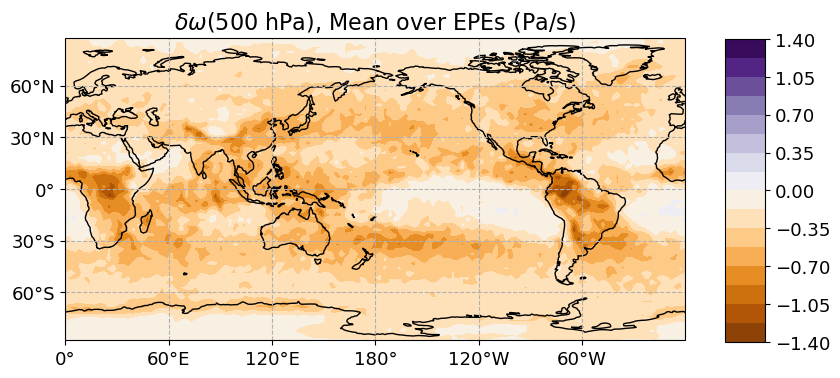

In [14]:
field_vals, lon_plt, lat_plt = process_for_map(da_wap_anom.mean(dim="time"))

draw_global_map(
    lon_plt,
    lat_plt,
    field_vals,
    title = r"$\delta\omega$($500$ hPa), Mean over EPEs (Pa/s)",
    filled = True,
    show_fig = True,
    save_fig = False,
    levels = 16,
    cmap = "PuOr",
    cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
    #bbox = [0, 360, -60, 60],
    vmin = -1.4,
    vmax = 1.4,
    draw_labels = False,
    label_contours = False,
    remove_cbar = False,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    # outfilename = "my_map" + ".png",
)

In [15]:
# Get the land fraction map
my_lf_path = "sftlf_fx_CanESM5-1_amip_r1i1p1f1_gn.nc"

da_lf = get_ds_areacell(
                    my_runid, 
                    my_experiment_name,
                    base_path = my_base_path,
                    areacell_path = my_lf_path,
).sftlf

In [16]:
land_mask = da_lf.where(da_lf >= 50, other = False).astype(bool)

In [17]:
def do_trimming(da, land_mask, lat_slice, fillval = -9999999999):
    da_trimmed = da.where(~land_mask).sel(lat = lat_slice)
    da_trimmed["time"] = da_trimmed.time.dt.floor("D")

    da_trimmed = da_trimmed.fillna(fillval) # avoids dealing with NaN's and cftime.DateTime's in the same array!

    return da_trimmed

In [18]:
my_lat_slice = slice(-60, 60)
da_wap_daily_trimmed = do_trimming(da_wap_daily, land_mask, my_lat_slice)
da_pr_daily_trimmed = do_trimming(da_pr_daily, land_mask, my_lat_slice)

In [19]:
da_wap_anom_trimmed = get_anom(da_wap_daily_trimmed, da_pr_daily_trimmed, year_range)

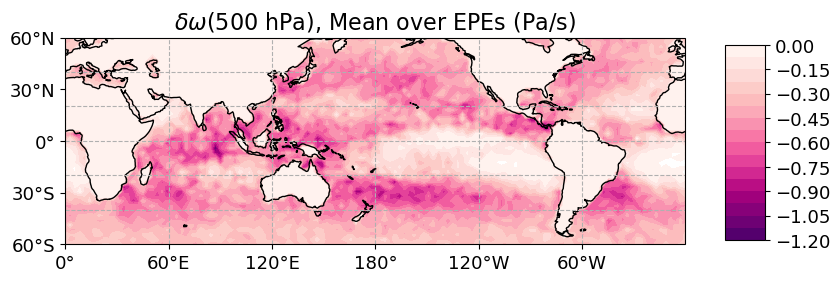

In [21]:
field_vals, lon_plt, lat_plt = process_for_map(da_wap_anom_trimmed.mean(dim="time"))

draw_global_map(
    lon_plt,
    lat_plt,
    field_vals,
    title = r"$\delta\omega$($500$ hPa), Mean over EPEs (Pa/s)",
    filled = True,
    show_fig = True,
    save_fig = True,
    levels = 16,
    cmap = "RdPu_r",
    cbar_params = [0.95, 0.33, 0.05, 0.325],
    bbox = [0, 360, -60, 60],
    vmin = -1.2,
    vmax = 0.,
    draw_labels = False,
    label_contours = False,
    remove_cbar = False,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    outfilename = "wap_anom_epes" + ".png",
)